#1. Import Dataset

In [1]:
import tensorflow as tf


In [2]:
from google.colab import drive
import numpy as np
import pandas as pd


drive.mount('/content/drive/', force_remount=True)

dir = '/content/drive/My Drive/TA/'
import sys
sys.path.insert(0, dir)


import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings
from CombinedDecays import CombinedDecays
import datetime


Mounted at /content/drive/


In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      print(f"Found GPU: {gpu.name}")
  except RuntimeError as e:
    print(e)
else:
  print("No GPU devices found.")

Found GPU: /physical_device:GPU:0


In [4]:
no2_df = pd.read_csv("/content/drive/MyDrive/TA/Dataset/no2.csv")
wind_df=  pd.read_csv("/content/drive/MyDrive/TA/Dataset/wind.csv")
no2_sea = pd.read_csv("/content/drive/MyDrive/TA/Dataset/Sea/NO2_Sea_wind.csv")

#2. Class Definition

In [6]:
import tensorflow as tf
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings

DTYPE='float32'

class MultiSigmaFourierFeatures(tf.keras.layers.Layer):
    def __init__(self, sigmas, mapping_size, trainable_B=False, **kwargs):
        super().__init__(**kwargs)
        self.sigmas = sigmas
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.fourier_layers = [
            FourierFeatureMapping(
                mapping_size=self.mapping_size,
                sigma=sigma,
                trainable_B=self.trainable_B
            ) for sigma in self.sigmas
        ]

    def call(self, inputs):
        outputs = [layer(inputs) for layer in self.fourier_layers]
        return tf.concat(outputs, axis=-1)



class FourierFeatureMapping(tf.keras.layers.Layer):
    def __init__(self, mapping_size=256, sigma=1.0, trainable_B=False, **kwargs):
        super(FourierFeatureMapping, self).__init__(**kwargs)
        self.mapping_size = mapping_size
        self.sigma = sigma
        self.trainable_B = trainable_B

    def build(self, input_shape):
        input_dim = input_shape[-1]
        # Use RandomNormal initializer with stddev = sigma
        self.B = self.add_weight(
            name="B_matrix",
            shape=(input_dim, self.mapping_size),
            initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=self.sigma),
            trainable=self.trainable_B
        )

    def call(self, inputs):
        proj = tf.matmul(inputs, self.B)
        return tf.concat([tf.sin(proj), tf.cos(proj)], axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({
            "mapping_size": self.mapping_size,
            "sigma": self.sigma,
            "trainable_B": self.trainable_B
        })
        return config

# Define model architecture for 2D spatial domain with time
class PINN_NeuralNet(tf.keras.Model):
    def __init__(self, lb, ub,
                 output_dim=1,
                 num_hidden_layers=8,
                 num_neurons_per_layer=20,
                 activation='tanh',
                 mapping_size=256,
                 sigma=1.0,
                 sigmas=[1.0, 3.0],
                 kernel_initializer='glorot_normal',
                 trainable_B=True,
                 **kwargs):
        super().__init__(**kwargs)
        self.lb = lb
        self.ub = ub
        self.num_hidden_layers = num_hidden_layers
        self.output_dim = output_dim
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.sigmas = sigmas
        self.scale = tf.keras.layers.Lambda(lambda x: 2.0*(x - lb)/(ub - lb) - 1.0)
        self.fourier_features = MultiSigmaFourierFeatures(sigmas=self.sigmas, mapping_size=self.mapping_size, trainable_B=True)
        # self.fourier_features = FourierFeatureMapping(mapping_size=mapping_size, sigma=sigma, trainable_B=trainable_B)

        # dummy_input = tf.keras.Input(shape=(3,))
        # _ = self.fourier_features(dummy_input)

        self.hidden = [tf.keras.layers.Dense(num_neurons_per_layer,
                                             activation=tf.keras.activations.get(activation),
                                             kernel_initializer=kernel_initializer)
                       for _ in range(self.num_hidden_layers)]
        self.out = tf.keras.layers.Dense(output_dim)


    def call(self, X):
        """Forward-pass through neural network."""
        X = tf.convert_to_tensor(X, dtype=tf.float32)  # Ensure X is a Tensor
        X = tf.reshape(X, (-1, 3))  # Ensure input is 2D (batch_size, features) for [t, x, y]
        Z = self.scale(X)
        Z = self.fourier_features(Z)
        for i in range(self.num_hidden_layers):
            Z = self.hidden[i](Z)
        return self.out(Z)


class PINN_PDESolver():
    def __init__(self, model, X_r, fun_r, get_r,lambd=1):
        self.model = model

        # Store collocation points
        # X_r = tf.convert_to_tensor(X_r, dtype=tf.float32)  # Ensure X_r is a Tensor
        self.t = X_r[:,0:1]
        self.x = X_r[:,1:2]
        self.y = X_r[:,2:3]
        self.lambd = lambd
        # Initialize history of losses and global iteration counter
        self.hist = []
        self.lambd_list = []  # Initialize lambda list here
        self.iter = 0
        self.fun_r = fun_r
        self.get_r_fn = get_r

    def get_r(self):
        return self.get_r_fn(t=self.t, x=self.x, y=self.y, model=self.model, lambd = self.lambd, fun_r=self.fun_r)

    def loss_fn(self, X, u):
        # X = tf.convert_to_tensor(X, dtype=tf.float32)
        # X = tf.reshape(X, (-1, 3))  # Ensure input is 3D [t, x, y]
        # u = tf.convert_to_tensor(u, dtype=tf.float32)

        # Compute phi_r
        r = self.get_r()
        phi_r = r

        # Initialize loss
        loss = phi_r

        return loss, phi_r
    @tf.function
    def get_grad(self, X, u):
        X = tf.convert_to_tensor(X, dtype=tf.float32)
        u = tf.convert_to_tensor(u, dtype=tf.float32)

        with tf.GradientTape() as tape:
            loss, phi_r = self.loss_fn(X, u)
        grad_theta = tape.gradient(loss, self.model.trainable_variables)

        return loss, grad_theta

    def solve_with_TFoptimizer(self, optimizer, X, u, inverse=True, N=None, min_loss=None, timeout=None):
        X = tf.convert_to_tensor(X, dtype=tf.float32)  # Ensure X is Tensor
        u = tf.convert_to_tensor(u, dtype=tf.float32)  # Ensure u is Tensor

        @tf.function
        def train_step():
          loss, grads = self.get_grad(X, u)
          optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
          return loss

        def loss_callback():
            loss = train_step()
            self.current_loss = loss.numpy()

            print(f"Iteration {self.iter}, Loss: {self.current_loss}")
            self.hist.append(self.current_loss)
            self.iter += 1

        start_time = time.time()
        if timeout is not None:
            while time.time() - start_time < timeout:
                loss_callback()
        elif N is not None:
            for _ in range(N):
                loss_callback()
        elif min_loss is not None:
            while self.current_loss > min_loss:
                loss_callback()

    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print('It {:05d}: l_u = {:10.8e} loss = {:10.8e}'.format(self.iter,self.phi_0_b,self.current_loss))
        self.hist.append(self.current_loss)
        self.iter+=1

    def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
        upred = self.model(tf.cast(test_data, DTYPE))  # shape: [N, 1]

        # Reshape into [Nt+1, Nx+1, Ny+1]
        Nt, Nx, Ny = len(t_unique) - 1, len(x_unique) - 1, len(y_unique) - 1
        U = upred.numpy().reshape(Nt+1, Nx+1, Ny+1)

        # Create meshgrid for visualization
        T, X, Y = np.meshgrid(t_unique, x_unique, y_unique, indexing='ij')
        self.T_pred, self.X_pred, self.Y_pred = T, X, Y

        return U

    def plot_solution_at_time(self, U=None, time_idx=0, **kwargs):
        # If upred has not been predicted
        if U is None:
            U = self.predict_solution()

        # Plot solution at specific time
        fig = plt.figure(figsize=(9,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(self.X_pred[time_idx], self.Y_pred[time_idx], U[time_idx], cmap='viridis', **kwargs)
        ax.set_xlabel('$x$')
        ax.set_ylabel('$y$')
        ax.set_zlabel('$u_\\theta(t,x,y)$')
        ax.set_title(f'Solution at t = {self.T_pred[time_idx,0,0]:.2f}')
        return ax

    def plot_loss_history(self, ax=None):
        if not ax:
            fig = plt.figure(figsize=(7,5))
            ax = fig.add_subplot(111)
        ax.semilogy(range(len(self.hist)), self.hist,'k-')
        ax.set_xlabel('$n_{epoch}$')
        ax.set_ylabel('$\\phi^{n_{epoch}}$')
        return ax



def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
    upred = self(tf.cast(test_data, DTYPE))  # shape: [N, 1]

    #     # Reshape into [Nt+1, Nx+1, Ny+1]
    # Nt, Nx, Ny = len(t_unique) - 1, len(x_unique) - 1, len(y_unique) - 1
    # U = upred.numpy().reshape(Nt+1, Nx+1, Ny+1)

    #     # Create meshgrid for visualization
    # T, X, Y = np.meshgrid(t_unique, x_unique, y_unique, indexing='ij')
    # self.T_pred, self.X_pred, self.Y_pred = T, X, Y

    return upred

def calculate_mae(u_pred, u_true):
    """Calculate Mean Absolute Error"""
    return np.mean(np.abs(u_true - u_pred))

def calculate_mape(u_pred, u_true, epsilon=1e-10):
    """Calculate Mean Absolute Percentage Error"""
    return 100 * np.mean(np.abs((u_true - u_pred) / (np.abs(u_true) + epsilon)))

def evaluate_solution(u_pred, u_true):
    """Evaluate solution using MAE and MAPE"""
    mae = calculate_mae(u_pred, u_true)
    mape = calculate_mape(u_pred, u_true)
    # r2 =   calculate_rel_l2(u_pred, u_true)

    return mae, mape

def calculate_rel_l2(u_pred, u_true, epsilon=1e-10):
    """Relative L2 norm error"""
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + epsilon)


def evaluate_param(lambda_pred, lambda_true):
    """Evaluate parameter using absolute error and percentage error"""
    abs_error = np.abs(lambda_true - lambda_pred)
    perc_error = 100 * abs_error / np.abs(lambda_true)
    return abs_error, perc_error

def plot_solution_slice(U, T, X, Y, time_idx=0):
    """Plot solution slice at specific time index"""
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X[time_idx], Y[time_idx], U[time_idx],
                          cmap='viridis', edgecolor='none')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('u(t,x,y)')
    ax.set_title(f'Solution at t = {T[time_idx,0,0]:.2f}')
    fig.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()


class Hybrid_IdentificationNet(PINN_NeuralNet):
    def __init__(self, initial_lambda, *args, **kwargs):
        # Call init of base class
        super().__init__(*args,**kwargs)
        self.initial_lambda = initial_lambda

        if isinstance(initial_lambda, (list, np.ndarray)):
            self.initial_lambda = np.array(initial_lambda, dtype=DTYPE)
        else:
            self.initial_lambda = initial_lambda

        # Initialize variable for lambda
        self.lambd = tf.Variable(initial_value=self.initial_lambda, trainable=True, dtype=DTYPE, constraint=lambda x: tf.clip_by_value(x, 1e-5, 10.0))
        self.lambd_list = []

    def build(self, input_shape):
           super().build(input_shape)  # Ensure layers are initialized
           self.built = True


    def add_param(self):
        try:
          len(self.initial_lambda)
          self.initial_lambda = np.array(self.initial_lambda, dtype=DTYPE)
        except TypeError as e:
          pass

    @property
    def trainable_variables(self):
        # Combine neural network weights with lambda parameter
        return super().trainable_variables + [self.lambd]

class Hybrid_IdentificationSolver(PINN_PDESolver):
    def solve_with_TFoptimizer(self, optim_fwd, optim_param, get_r_param, X, u,
                               N_fwd=None, min_loss_fwd=None, timeout_fwd=None,
                               N_param=None, min_loss_param=None, timeout_param=None, modified=False, **kwargs):
        self.changed = False
        self.lambd_list = []
        super().solve_with_TFoptimizer(optim_fwd, X, u, N=N_fwd, min_loss=min_loss_fwd, timeout=timeout_fwd, **kwargs)

        # Add parameters after fitting
        # with given data.
        self.model.add_param()
        self.changed = True

        print('\n\nFinding PDE parameters.')

        if modified is True:

            @tf.function
            def train_step_param():
                loss, grad_theta = get_r_param()

                # Perform gradient descent step, update the weights of the model.
                optim_param.apply_gradients(zip([grad_theta], [self.model.lambd]))
                return loss

            def loss_callback():
                loss = train_step_param()

                self.current_loss = loss.numpy()
                callback()

        else:
            @tf.function
            def train_step_param_unmodified():
                 with tf.GradientTape() as tape:
                    tape.watch(self.model.lambd)
                    # phi_r is calculated only after
                    # variables are added.
                    # Compute phi_r
                    r = self.get_r()
                    loss = r

                 grad_lambd = tape.gradient(loss, self.model.lambd)
                 optim_param.apply_gradients(zip([grad_lambd], [self.model.lambd]))
                 return loss


            def loss_callback():
                loss = train_step_param_unmodified()
                self.current_loss = loss.numpy()
                callback()



        def callback():
                lambd = self.model.lambd.numpy()
                self.model.lambd_list.append(lambd)

                if self.iter % 10 == 0:
                    print('It {:05d}: loss = {:10.8e} lambda = '.format(self.iter, self.current_loss) + str(lambd))

                self.hist.append(self.current_loss)
                self.iter += 1

        if N_param is not None:
            for _ in range(N_param):
                loss_callback()

            print ('{} iterations reached.'.format(N_param))

        elif min_loss_param is not None:
            while True:
                loss_callback()

                if self.current_loss < min_loss_param:
                    print ('Loss is reached. Current loss: {:10.8e}'.format(self.current_loss))
                    break

        elif timeout_param is not None:
            t0 = time.time()
            stop_after = time.time() + timeout_param

            while True:
                loss_callback()

                if time.time() > stop_after:
                    print ('Timeout is reached. Time elapsed: {} seconds'.format(time.time()-t0))
                    break

    def loss_fn(self, X, u):
        # Initialize loss
        loss = 0
        phi_r = 0

        # phi_r is calculated only after
        # variables are added.
        if self.changed is not False:
            # Compute phi_r
            r = self.get_r()
            phi_r =r
            loss += phi_r

        else:
            u_pred = self.model(X)
            loss += tf.reduce_mean(tf.square(u - u_pred))

        return loss, phi_r

    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print('It {:05d}: l_u = {:10.8e} loss = {:10.8e}'.format(self.iter,self.phi_0_b,self.current_loss))
            # print('It {:05d}: loss = {:10.8e}'.format(self.iter,self.current_loss))
        self.hist.append(self.current_loss)
        self.iter+=1

# 3. Data PreProcessing and Training-Testing Split

In [7]:
no2_df = no2_df.drop(columns=['Unnamed: 0'])
no2_sea = no2_sea.drop(columns=['Unnamed: 0'])
no2_df.dropna(inplace = True)


In [8]:
no2_sea.loc[no2_sea.index[-528:], 'date'] = pd.to_datetime(no2_sea.loc[no2_sea.index[-528:], 'date']).dt.date

In [9]:
no2_df['date'] = pd.to_datetime(no2_df['date'])
start_date = datetime.datetime(2023, 5, 1)
no2_df = no2_df[(no2_df['date'] >= start_date)]

no2_sea['date'] = pd.to_datetime(no2_sea['date'])
start_date = datetime.datetime(2023, 5, 1)
no2_sea = no2_sea[(no2_sea['date'] >= start_date)]
no2_sea.sort_values(by=['date','longitude','latitude'], inplace=True)

In [10]:
no2_sea

,latitude,longitude,date,WS10M,WD10M,MeanNO2
1560,-6.583673,104.968469,2023-05-01,3.10,259.6,5.396200e-06
1011,-6.678569,104.974697,2023-05-01,3.10,259.6,8.490805e-08
2106,-6.490722,104.985761,2023-05-01,3.10,259.6,1.329365e-05
480,-6.767207,105.003719,2023-05-01,3.28,263.4,6.407810e-06
2654,-6.423209,105.014849,2023-05-01,3.10,259.6,9.833321e-06
...,...,...,...,...,...,...
110655,-6.977997,108.959799,2025-04-29,2.78,151.1,1.694724e-05
162110,-7.670531,108.960063,2025-04-29,3.26,127.9,1.329156e-05
112344,-6.688445,108.967292,2025-04-29,4.28,140.0,1.914681e-05
111222,-6.876551,108.974448,2025-04-29,2.78,151.1,2.544793e-05


In [ ]:

no2_sea = no2_sea[["x_coord","y_coord","NO2_mean","u10","v10","date"]]
no2_sea["city"] = "Sea"

wind_df['date'] = pd.to_datetime(wind_df['date'])
no2_df['date'] = pd.to_datetime(no2_df['date'])
df_all = pd.merge(no2_df, wind_df[['date', 'city', 'u10', 'v10']],
                     on=['date', 'city'], how='left')

df_all = pd.concat([df_all,no2_sea],axis=0)

In [12]:
df_all.describe(include="all")

,x_coord,y_coord,date,NO2_mean,city,u10,v10
count,191728.000000,191728.000000,191728,1.917280e+05,191728,191728.000000,191728.000000
unique,NaN,NaN,NaN,NaN,41,NaN,NaN
top,NaN,NaN,NaN,NaN,Sea,NaN,NaN
freq,NaN,NaN,NaN,NaN,172290,NaN,NaN
mean,107.101734,-6.739350,2024-03-31 22:12:49.389969408,2.726761e-05,NaN,-1.674285,1.894296
min,104.968469,-7.964794,2023-05-01 00:00:00,2.033114e-09,NaN,-3.408601,-0.356253
25%,106.082504,-7.370404,2023-09-29 00:00:00,1.273526e-05,NaN,-2.476696,1.127062
50%,107.101275,-6.681646,2024-04-05 00:00:00,1.917604e-05,NaN,-1.634715,2.108074
75%,108.240269,-6.094171,2024-09-11 00:00:00,2.967739e-05,NaN,-0.977184,2.745287
max,108.980321,-5.627853,2025-04-29 00:00:00,7.873459e-04,NaN,0.022454,3.950286


In [13]:
df_all

,x_coord,y_coord,date,NO2_mean,city,u10,v10
0,106.166337,-6.123216,2023-05-01,0.000039,KotaSerang,-0.026413,0.286796
1,107.414924,-6.897186,2023-05-01,0.000026,BandungBarat,-0.419523,0.591405
2,106.651931,-6.182884,2023-05-01,0.000092,KotaTangerang,-0.485871,-0.356253
3,107.788766,-7.359739,2023-05-01,0.000026,Garut,-1.483096,1.613819
4,108.466208,-7.434468,2023-05-01,0.000056,Ciamis,-0.748268,1.851568
...,...,...,...,...,...,...,...
110655,108.959799,-6.977997,2025-04-29,0.000017,Sea,-0.699851,2.291891
162110,108.960063,-7.670531,2025-04-29,0.000013,Sea,-0.947323,1.998138
112344,108.967292,-6.688445,2025-04-29,0.000019,Sea,-1.517700,2.272919
111222,108.974448,-6.876551,2025-04-29,0.000025,Sea,-0.627454,2.108943


In [ ]:
no2_sea["u10"]  = no2_sea.groupby(['x_coord','y_coord'])['u10'].transform('mean')
no2_sea["v10"]  = no2_sea.groupby(['x_coord','y_coord'])['v10'].transform('mean')
wind_df['u10'] = wind_df.groupby('city')['u10'].transform('mean')
wind_df['v10'] = wind_df.groupby('city')['v10'].transform('mean')
no2_df['date'] = pd.to_datetime(no2_df['date'])
df_all = pd.merge(no2_df, wind_df[['date', 'city', 'u10', 'v10']],
                     on=['date', 'city'], how='left')

df_all = pd.concat([df_all,no2_sea],axis=0)

In [14]:
#Convert to Numerical Value
df_all['time'] = (df_all['date'] - df_all['date'].min()).dt.days
scale = 1e-5
df_all.NO2_mean = df_all.NO2_mean/scale


In [ ]:
filtered_list = []

full_dates = pd.date_range(start=df_all['date'].min(),end=df_all['date'].max(),freq='D')
coords = df_all[['x_coord', 'y_coord']].drop_duplicates()
full_index = pd.MultiIndex.from_frame(
    coords.merge(pd.DataFrame({'date': full_dates}), how='cross')
)

df2 = (
    df_all.set_index(['x_coord', 'y_coord', 'date'])
    .reindex(full_index)
    .reset_index()
    .rename(columns={'level_0': 'x_coord', 'level_1': 'y_coord', 'level_2': 'date'})
)

df2['NO2_mean'] = (df2.groupby(['x_coord', 'y_coord'])['NO2_mean'].transform(lambda s: s.interpolate(method='linear', limit_direction='both')))

np.random.seed(42)
for city, subdf in df_all.groupby('city'):
    if city == 'Sea':
        # Filter per (x_coords, y_coords) within 'Sea'
        for (x, y), subsubdf in subdf.groupby(['x_coord', 'y_coord']):
            signal = subsubdf['NO2_mean'].values
            n = len(signal)

            # Low-pass filter
            fft_vals = np.fft.fft(signal)
            freqs = np.fft.fftfreq(n, d=1)
            cutoff = 0.1
            mask = np.abs(freqs) < cutoff
            filtered_fft = fft_vals * mask
            filtered_signal = np.fft.ifft(filtered_fft).real

            subsubdf = subsubdf.copy()
            subsubdf['NO2_filtered'] = filtered_signal
            filtered_list.append(subsubdf)
    else:
        # Process non-Sea cities as usual
        signal = subdf['NO2_mean'].values
        n = len(signal)

        fft_vals = np.fft.fft(signal)  # magnitude and phase (angle) (V(s))
        freqs = np.fft.fftfreq(n, d=1)  # frequency of the i-th component (s)
        cutoff = 0.1
        mask = np.abs(freqs) < cutoff #H(s)
        filtered_fft = fft_vals * mask #W(s) = H(s)* V(s)
        filtered_signal = np.fft.ifft(filtered_fft).real

        subdf = subdf.copy()
        subdf['NO2_filtered'] = filtered_signal
        filtered_list.append(subdf)

# Combine all back
filtered_df = pd.concat(filtered_list)
filtered_df = df_all.merge(
    filtered_df[['date', 'city', 'x_coord', 'y_coord', 'NO2_filtered']],
    on=['date', 'city', 'x_coord', 'y_coord'],
    how='left'
)

In [16]:
cities = filtered_df['city'].unique()

for city in cities:
    city_df = filtered_df[filtered_df['city'] == city]

    plt.figure(figsize=(12, 4))
    plt.plot(city_df['date'], city_df['NO2_mean'], label='Original', alpha=0.6)
    plt.plot(city_df['date'], city_df['NO2_filtered'], label='Filtered', linewidth=2)
    plt.title(f'NO₂ Time Series – {city}')
    plt.xlabel('Date')
    plt.ylabel('NO₂ Concentration')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [17]:
filtered_df = filtered_df[filtered_df.NO2_filtered>=0]
filtered_df.describe()

,x_coord,y_coord,date,NO2_mean,u10,v10,time,NO2_filtered
count,191695.000000,191695.000000,191695,191695.000000,191695.000000,191695.000000,191695.000000,191695.000000
mean,107.101956,-6.739462,2024-03-31 21:57:31.977360128,2.726966,-1.674456,1.894319,335.914953,2.727295
min,104.968469,-7.964794,2023-05-01 00:00:00,0.000203,-3.408601,-0.356253,0.000000,0.014137
25%,106.082504,-7.370404,2023-09-29 00:00:00,1.273537,-2.476696,1.127062,151.000000,1.374342
50%,107.101275,-6.681646,2024-04-05 00:00:00,1.917703,-1.634715,2.108074,340.000000,1.973526
75%,108.240269,-6.094171,2024-09-11 00:00:00,2.967950,-0.977184,2.745287,499.000000,2.944250
max,108.980321,-5.627853,2025-04-29 00:00:00,78.734593,0.022454,3.950286,729.000000,35.611021
std,1.209662,0.680952,NaN,3.009368,0.875497,1.204047,205.986270,2.531330


In [18]:
np.random.seed(42)


shuffled_df = filtered_df.sample(frac=1).reset_index(drop=True)

split_ratio = 0.7

# Calculate the number of training samples
train_size = int(split_ratio * len(shuffled_df))

# Split the data
train_df = shuffled_df[:train_size]
test_df = shuffled_df[train_size:]

# Convert to tensors
X_train = tf.convert_to_tensor(train_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_train =  tf.convert_to_tensor(train_df['NO2_filtered'].values.reshape(-1, 1), dtype= tf.float32)

X_test =  tf.convert_to_tensor(test_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_test =  tf.convert_to_tensor(test_df['NO2_filtered'].values.reshape(-1, 1), dtype= tf.float32)

W_u =tf.convert_to_tensor(train_df[[ 'u10']].values, dtype= tf.float32)
W_v =tf.convert_to_tensor(train_df[['v10']].values, dtype= tf.float32)

In [19]:
X_train

<tf.Tensor: shape=(134186, 3), dtype=float32, numpy=
array([[532.       , 105.118355 ,  -6.9626536],
       [422.       , 106.019356 ,  -5.998129 ],
       [710.       , 105.36356  ,  -7.0713553],
       ...,
       [338.       , 108.363235 ,  -7.867246 ],
       [666.       , 106.109924 ,  -5.8795695],
       [173.       , 107.299065 ,  -6.737873 ]], dtype=float32)>

In [20]:
u_train

<tf.Tensor: shape=(134186, 1), dtype=float32, numpy=
array([[ 1.3696043],
       [11.113276 ],
       [ 2.1920397],
       ...,
       [ 1.2950594],
       [ 5.3553967],
       [ 5.3786726]], dtype=float32)>

In [21]:
X_test

<tf.Tensor: shape=(57509, 3), dtype=float32, numpy=
array([[621.       , 106.224724 ,  -5.891141 ],
       [701.       , 108.56532  ,  -5.979962 ],
       [425.       , 108.56028  ,  -7.0042048],
       ...,
       [403.       , 107.98065  ,  -6.094171 ],
       [133.       , 108.363235 ,  -6.1876454],
       [ 80.       , 107.65512  ,  -6.244249 ]], dtype=float32)>

In [22]:
u_test

<tf.Tensor: shape=(57509, 1), dtype=float32, numpy=
array([[7.61967  ],
       [2.4532785],
       [1.9744536],
       ...,
       [1.7757777],
       [1.2669439],
       [2.9264426]], dtype=float32)>

In [23]:
W_u

<tf.Tensor: shape=(134186, 1), dtype=float32, numpy=
array([[-3.2943227 ],
       [-0.02641337],
       [-2.5726087 ],
       ...,
       [-2.572979  ],
       [-0.50455993],
       [-0.606351  ]], dtype=float32)>

In [24]:
W_v

<tf.Tensor: shape=(134186, 1), dtype=float32, numpy=
array([[ 3.779621  ],
       [ 0.28679556],
       [ 3.650801  ],
       ...,
       [ 2.3090901 ],
       [ 0.32717294],
       [-0.15720104]], dtype=float32)>

# Persiapan Arsitektur PINN

In [25]:
lb = filtered_df[['time','x_coord', 'y_coord']].min().values
ub = filtered_df[['time','x_coord', 'y_coord']].max().values

In [26]:
arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'tanh', 'trainable_B':True, 'sigmas':[1.0,2.0], 'mapping_size':64}
n_models = 5

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = Hybrid_IdentificationNet(initial_lambda=0.0, lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

#4. Constructing Loss Function

### Inverse Method

In [27]:
def get_r_inv(t, x, y, model, lambd, fun_r,u_data=u_train):
    """
    Computes the residuals of the PDE using automatic differentiation.
    """

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2

    return fun_r(t, x, y, u_pred, u_t, u_x,u_y, u_xx, u_yy, model)

def fun_r_inv(t, x, y, u_pred, u_t,u_x,u_y, u_xx, u_yy, model, u_data= u_train):

    pde_residual = scale*(u_t + W_u * u_x + W_v * u_y- model.lambd * (u_xx + u_yy))
    return tf.reduce_mean(tf.square(pde_residual))

def get_r_param(t, x, y,model):

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)

    del tape
    del tape2

    with tf.GradientTape(persistent=True) as tape_lambd:
      tape_lambd.watch(model.lambd)
      pde_residual = scale*(u_t + W_u * u_x + W_v * u_y- model.lambd * (u_xx + u_yy))

      loss = tf.reduce_mean(tf.square(pde_residual))

    g = tape_lambd.gradient(loss, model.lambd)

    del tape_lambd

    return loss, g


### Forward Method

In [28]:

def get_r_fwd(t, x, y, model, lambd, fun_r,u_data=u_train):
    """
    Computes the residuals of the PDE using automatic differentiation.
    """
    t = tf.convert_to_tensor(t, dtype=tf.float32)
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    y = tf.convert_to_tensor(y, dtype=tf.float32)

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)
            u = model(tf.concat([t, x,y], axis=1))  # Ensure proper tensor shape
        u_t = tape2.gradient(u, t)
        u_x = tape2.gradient(u, x)
        u_y = tape2.gradient(u, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2
    return fun_r_fwd(t, x, y, u, u_t,u_x,u_y,u_xx, u_yy, model,lambd,u_data)

def fun_r_fwd(t, x, y, u, u_t,u_x,u_y, u_xx, u_yy, model,lambd, u_data= u_train, weight_pde=1, weight_data=1000):

    pde_residual =scale*(u_t + W_u * u_x + W_v * u_y-lambd * (u_xx + u_yy))
    pde_loss = tf.reduce_mean(tf.square(pde_residual))

    u_pred_data = u
    data_loss = tf.reduce_mean(tf.square((u_pred_data - u_data)))

    total_loss = weight_pde * pde_loss + weight_data*data_loss
    tf.print("PDE Loss:", pde_loss, "Data Loss:",data_loss, "Total Loss:", total_loss)
    return total_loss

# Training Data and Evaluate Data

## PDP Model 1 Inverse

In [29]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

In [30]:
timeout = 300
initial_lambdas = [0.5,1,1.5]
path = dir + "NO2Model/Fourier/Fourier2_inv_tanh/"

old_timeout = timeout
models_Adam = [None] * n_models
hists_Adam = [None] * n_models

for i in range(n_models):
  timeout = old_timeout
  models_Adam[i] = []
  hists_Adam[i] = []

  for j in range(len(initial_lambdas)):
    print('{:s}\nIteration: {:d} Initial lambda: {}\n{:s}'.format(50*'-',i+1,initial_lambdas[j],50*'-'))
    # Prepare models' architecture
    tf.random.set_seed(i + j)
    models_Adam[i].append(Hybrid_IdentificationNet(initial_lambda=initial_lambdas[j], lb=lb, ub=ub, **arch))

    models_Adam[i][j].build((None, 3))

    # Copy weights from the previous model instance to make every iteration comparable
    models_Adam[i][j].set_weights(models[i].get_weights())

    # Assigning initial lambda
    # models_Adam[i][j].trainable_variables[-1].assign(initial_lambdas[j])
    models_Adam[i][j].initial_lambda = initial_lambdas[j]

    # Prepare optimizer
    optim_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)
    optim_inv_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)

    # Initialize solver
    solver_Adam = Hybrid_IdentificationSolver(models_Adam[i][j], X_train,fun_r_inv, get_r_inv)

    # Train models
    print('\n\nAdam\n')
    solver_Adam.solve_with_TFoptimizer(optim_Adam, optim_inv_Adam, get_r_param, X_train, u_train, timeout_param=timeout*0.2, timeout_fwd=timeout*0.8)

    # Store evolution of lambdas and hists
    hists_Adam[i].append([models_Adam[i][j].lambd_list, solver_Adam.hist])

    print('\n\n\n')

--------------------------------------------------
Iteration: 1 Initial lambda: 0.5
--------------------------------------------------


Adam



/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:774: UserWarning: Gradients do not exist for variables ['Variable:0'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Streaming output truncated to the last 5000 lines.
Iteration 11831, Loss: 0.07593611627817154
Iteration 11832, Loss: 0.07593692094087601
Iteration 11833, Loss: 0.07594431191682816
Iteration 11834, Loss: 0.07594019919633865
Iteration 11835, Loss: 0.07591252774000168
Iteration 11836, Loss: 0.07588409632444382
Iteration 11837, Loss: 0.07587600499391556
Iteration 11838, Loss: 0.07587628811597824
Iteration 11839, Loss: 0.07589828968048096
Iteration 11840, Loss: 0.0758977085351944
Iteration 11841, Loss: 0.07589895278215408
Iteration 11842, Loss: 0.0758959949016571
Iteration 11843, Loss: 0.07592391222715378
Iteration 11844, Loss: 0.07595217227935791
Iteration 11845, Loss: 0.07593473792076111
Iteration 11846, Loss: 0.07592485100030899
Iteration 11847, Loss: 0.07592616230249405
Iteration 11848, Loss: 0.07593143731355667
Iteration 11849, Loss: 0.07591702789068222
Iteration 11850, Loss: 0.07587341964244843
Iteration 11851, Loss: 0.07583063095808029
Iteration 11852, Loss: 0.07582078874111176
Itera

In [31]:
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    models_Adam[i][j].save_weights(path+"_"+str(i)+"_model_Adam_"+str(j)+".weights.h5", 'h5')
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv", hists_Adam[i][j][1], delimiter=",")

for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/lambd_Adam_" + str(i) + "_" + str(j) + ".csv", hists_Adam[i][j][0], delimiter=",")

In [32]:
hists_Adam1 = [None] * n_models

for i in range(n_models):
    hists_Adam1[i] = []

    for j in range(len(initial_lambdas)):
        hists_Adam1[i].append(pd.read_csv(path + "/loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv",header=None).transpose())

### Loss Graph

len Atempt-0 and init lambda 0.5:  18811
len Atempt-0 and init lambda 1:  18947
len Atempt-0 and init lambda 1.5:  19123
\\
len Atempt-1 and init lambda 0.5:  18918
len Atempt-1 and init lambda 1:  18951
len Atempt-1 and init lambda 1.5:  19011
\\
len Atempt-2 and init lambda 0.5:  18879
len Atempt-2 and init lambda 1:  19155
len Atempt-2 and init lambda 1.5:  18966
\\
len Atempt-3 and init lambda 0.5:  19075
len Atempt-3 and init lambda 1:  19071
len Atempt-3 and init lambda 1.5:  18861
\\
len Atempt-4 and init lambda 0.5:  18996
len Atempt-4 and init lambda 1:  19182
len Atempt-4 and init lambda 1.5:  18989
\\


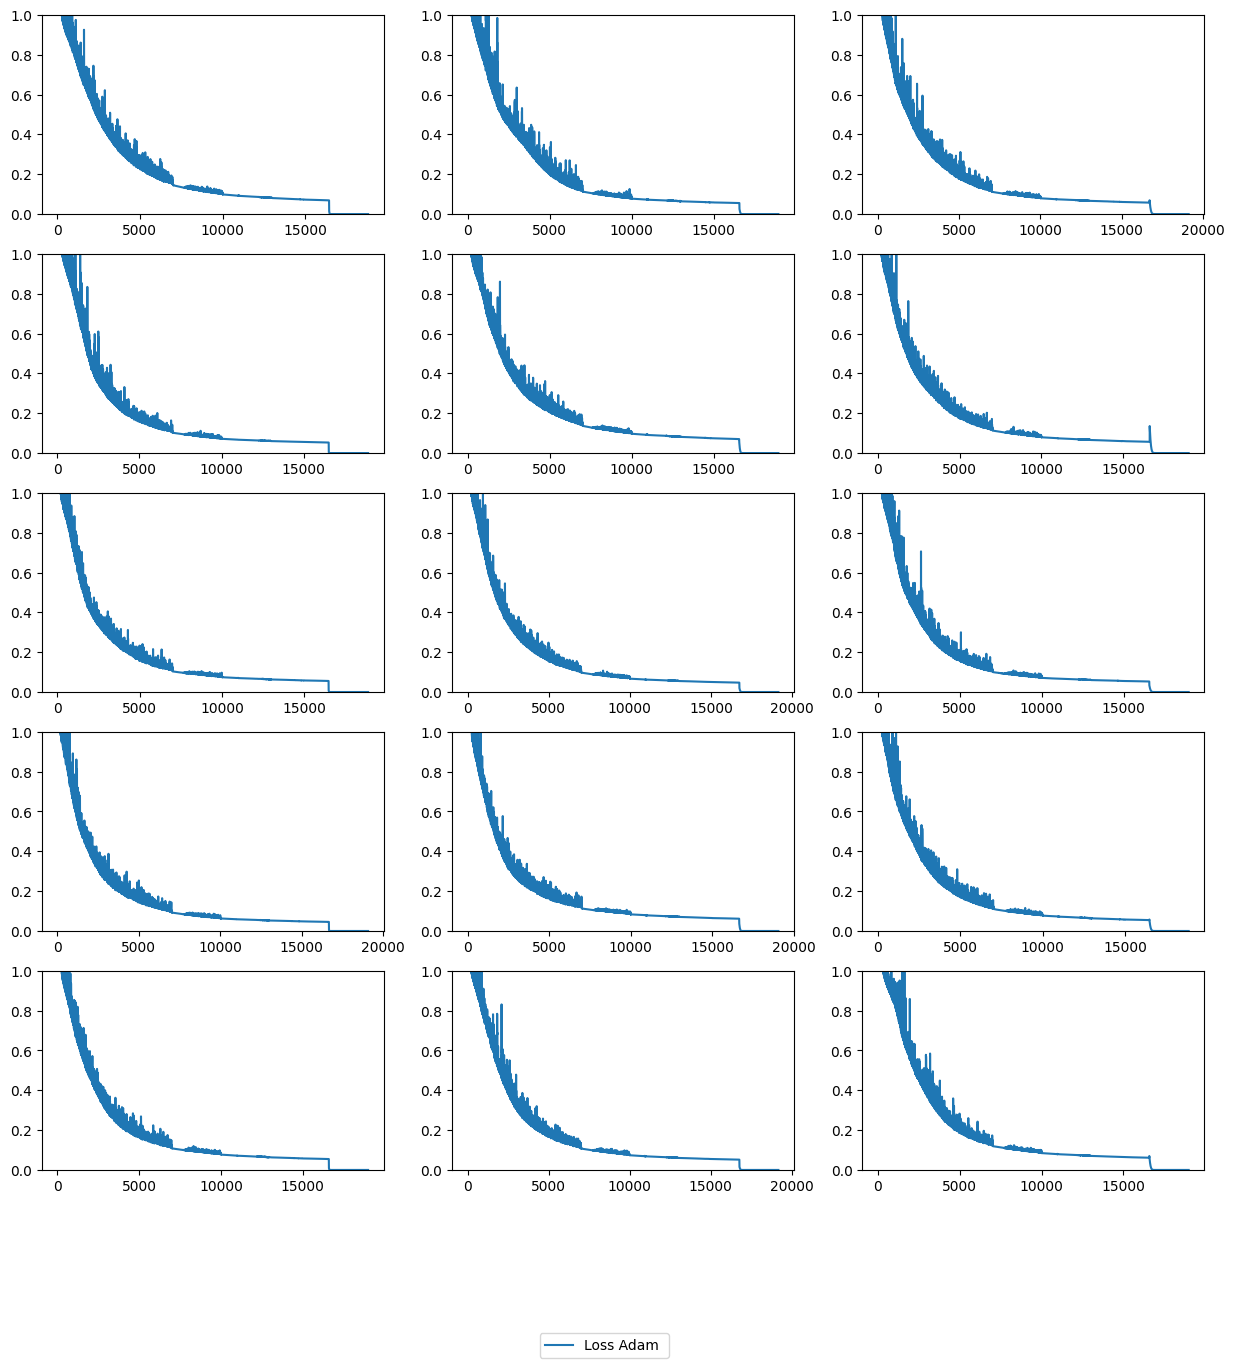

In [35]:
# fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(15,5))

fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(15,15))

for i in range(n_models):
  axes[i,0].plot(np.linspace(0, len(hists_Adam1[i][0].transpose()),len(hists_Adam1[i][0].transpose())), hists_Adam1[i][0].transpose())
  axes[i,0].set_ylim([0,1])

  axes[i,1].plot(np.linspace(0, len(hists_Adam1[i][1].transpose()), len(hists_Adam1[i][1].transpose())), hists_Adam1[i][1].transpose())
  axes[i,1].set_ylim([0,1])

  axes[i,2].plot(np.linspace(0, len(hists_Adam1[i][2].transpose()), len(hists_Adam1[i][2].transpose())), hists_Adam1[i][2].transpose())
  axes[i,2].set_ylim([0,1])
  # axes[0].plot(np.linspace(0, len(hists_Adam1[i][0].transpose()),len(hists_Adam1[i][0].transpose())), hists_Adam1[i][0].transpose())
  # axes[0].set_ylim([0,1])

  # axes[1].plot(np.linspace(0, len(hists_Adam1[i][1].transpose()), len(hists_Adam1[i][1].transpose())), hists_Adam1[i][1].transpose())
  # axes[1].set_ylim([0,1])

  # axes[2].plot(np.linspace(0, len(hists_Adam1[i][2].transpose()), len(hists_Adam1[i][2].transpose())), hists_Adam1[i][2].transpose())
  # axes[2].set_ylim([0,1])


  print(f"len Atempt-{i} and init lambda {initial_lambdas[0]}: ",len(hists_Adam1[i][0].transpose()))
  print(f"len Atempt-{i} and init lambda {initial_lambdas[1]}: ",len(hists_Adam1[i][1].transpose()))
  print(f"len Atempt-{i} and init lambda {initial_lambdas[2]}: ",len(hists_Adam1[i][2].transpose()))
  # print(f"len Atempt-{i} and init lambda {initial_lambdas[3]}: ",len(hists_Adam1[i][3].transpose()))

  print("\\\\")

# timeout = 250
cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]

# pad = 5 # in points


# for ax, col in zip(axes[0], cols):
#   ax.annotate(col, xy=(0.5, 1.05), xytext=(0, pad),
#               xycoords='axes fraction', textcoords='offset points',
#               size='large', ha='center', va='baseline')

# for ax, row in zip(axes[:,0], rows):
#   ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
#               xycoords=ax.yaxis.label, textcoords='offset points',
#               size='large', ha='right', va='center')

# fig.tight_layout()

fig.legend(['Loss Adam '], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

### Predict and Evaluate Inverse Problem

In [42]:
def lambdas(hists, iter_model, iter_init):
  return hists[iter_model][iter_init][0][-1]

df = pd.DataFrame(columns=['Adam_0.5','Adam_1','Adam_1.5'])
df = df.round(10)

for i in range(n_models):
  x = []
  for j in range(len(initial_lambdas)):
    x.append(lambdas(hists_Adam, i, j))

  df.loc['Attempt '+str(i+1)] = x

print("Lambda Prediction Given U(x,t)")
df

Lambda Prediction Given U(x,t)


,Adam_0.5,Adam_1,Adam_1.5
Attempt 1,0.000046,0.000122,0.000071
Attempt 2,0.000142,0.000010,0.000138
Attempt 3,0.000010,0.000010,0.000125
Attempt 4,0.000010,0.000150,0.000156
Attempt 5,0.000010,0.000212,0.000075


In [43]:
print(df.mean(axis=0).round(10))
df.loc['Average'] = df.mean(axis=0)


Adam_0.5    0.000044
Adam_1      0.000101
Adam_1.5    0.000113
dtype: float32


In [44]:
df.loc['StdDev'] = df.std(axis=0, ddof=1)
df.loc['CV'] = df.loc['StdDev'] / df.loc['Average']
df.loc[['Average', 'StdDev', 'CV']] = df.loc[['Average', 'StdDev', 'CV']].round(10)
print(df.tail(3))

         Adam_0.5    Adam_1  Adam_1.5
Average  0.000044  0.000101  0.000113
StdDev   0.000051  0.000080  0.000034
CV       1.170778  0.790411  0.303758


## PDP Model 1 Forward

In [45]:
n_models = 5
arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'tanh', 'trainable_B':True, 'sigmas':[1.0,2.0], 'mapping_size':64}

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = PINN_NeuralNet(lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'pinn__neural_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'pinn__neural_net_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'pinn__neural_net_2', however 

In [46]:
path = dir + "NO2Model/Fourier/Fourier2_fwd_tanh/"

In [47]:
lr_comb_param = {'boundaries': [6000,7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [6000, 7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.00531441,
  0.002657205,
  0.0013286025,
  0.00066430125,
  0.000332150625,
  0.0001660753125,
  8.303765625e-05,
  4.1518828125e-05],
 'values_steps': [2, 2, 2, 2, 2, 2, 2],
 'name': None}

Text(0.5, 1, 'Combined Learning Rate')

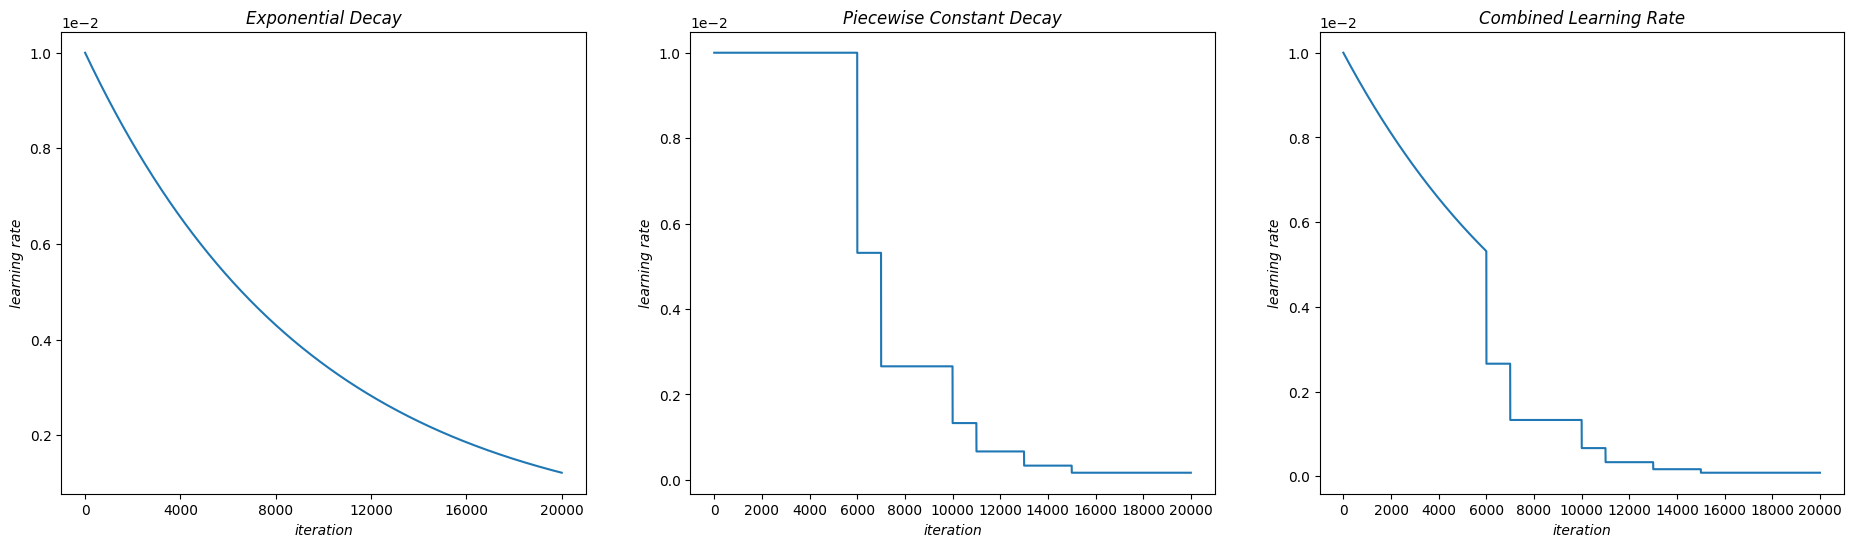

In [48]:
import numpy as np
import matplotlib.pyplot as plt

N = 20000  # Extended range

fig = plt.figure(figsize=(23, 6))

# ExponentialDecay
initial_learning_rate = lr_comb.initial_learning_rate
decay_steps = lr_comb.decay_steps
decay_rate = lr_comb.decay_rate

learning_rate = []
for i in range(N+1):
    lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    learning_rate.append(lr)

plt.subplot(1, 3, 1)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 4000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Exponential Decay', y=1, fontstyle='italic')

# Piecewise Constant Decay
boundaries = lr_comb.boundaries
values = lr_comb.values

learning_rate = []
for i in range(N+1):
    for j in range(len(boundaries)):
        if i <= boundaries[0]:
            lr = lr_comb.initial_learning_rate
        elif i <= boundaries[j]:
            lr = values[j-1]
            break
        else:
            lr = values[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 2)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Piecewise Constant Decay', y=1, fontstyle='italic')

# Extended Combined Decay
boundaries = lr_comb.boundaries
values_steps = lr_comb.values_steps  # should be a list like [2, 2, 2, ...]
if isinstance(values_steps, int):
    values_steps = [values_steps] * (len(boundaries))  # Make uniform if scalar

i_stop = boundaries[0]
learning_rate = []

learning_rate = []
i_stop = boundaries[0]

for i in range(N+1):
    if i <= i_stop:
        lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    else:
        for j in range(1, len(boundaries)):
            if boundaries[j-1] < i <= boundaries[j]:
                if i == boundaries[j-1] + 1:
                    # first step into this boundary: decay from previous segment
                    prev_lr = learning_rate[-1]
                    lr = prev_lr / values_steps[j-1]
                else:
                    lr = learning_rate[-1]  # maintain constant
                break
        else:
            # After the last boundary
            lr = learning_rate[-1] / values_steps[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 3)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0,0))
plt.title('Combined Learning Rate', y=1, fontstyle='italic')



In [60]:
pred_lambda = list(df.loc['Average'])
pred_lambda

[4.360339880804531e-05, 0.0001009086990961805, 0.00011290339898550883]

In [61]:
timeout = 1200
start_from = 1


models_Adam_comb = [None]*n_models
hists_Adam_comb = [None]*n_models


for i in range(start_from - 1, n_models):
    models_Adam_comb[i] = []
    hists_Adam_comb[i] = []
    for j, lambd_val in enumerate(pred_lambda):
        print('{:s}\nModel Iteration: {:d}, Lambda Iteration: {:d}\n{:s}'.format(
            50*'-', i+1, j+1, 50*'-'))

        tf.random.set_seed(i + j)  # Use a combined seed for reproducibility

        # Build and initialize model
        models_Adam_comb[i].append(PINN_NeuralNet(lb, ub, **arch))
        models_Adam_comb[i][j].build(input_shape=(None, 3))

        # Set weights and lambda from base model
        models_Adam_comb[i][j].set_weights(models[i].get_weights())
        # Prepare optimizer
        optim_Adam_comb = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay =1e-1)

        # Initialize solver
        solver = PINN_PDESolver(models_Adam_comb[i][j], X_train, fun_r_fwd, get_r_fwd,lambd_val)

        # Train the model
        print('\n\nAdam - Combined Learning Rate\n')
        solver.solve_with_TFoptimizer(optim_Adam_comb, X_train, u_train, timeout=timeout)

        # Store training history
        hists_Adam_comb[i].append(solver.hist)

        print('\n\n\n')

Output hidden; open in https://colab.research.google.com to view.

In [62]:
for i in range(n_models):
  for j in range(len(pred_lambda)):
    models_Adam_comb[i][j].save_weights(path+"_"+str(i)+"_model_Adam_comb_"+str(j)+".weights.h5", 'h5')


for i in range(n_models):
  for j in range(len(pred_lambda)):
    np.savetxt(path + "loss/hist_Adam_comb_" + str(i) + "_" + str(j) + ".csv", hists_Adam_comb[i][j], delimiter=",")

### Loss Function

len Attempt-0 Lambda ke- 0:  12807
len Attempt-0 Lambda ke- 1:  12788
len Attempt-0 Lambda ke- 2:  12785
\\
len Attempt-1 Lambda ke- 0:  12791
len Attempt-1 Lambda ke- 1:  12762
len Attempt-1 Lambda ke- 2:  12786
\\
len Attempt-2 Lambda ke- 0:  12781
len Attempt-2 Lambda ke- 1:  12779
len Attempt-2 Lambda ke- 2:  12776
\\
len Attempt-3 Lambda ke- 0:  12738
len Attempt-3 Lambda ke- 1:  12769
len Attempt-3 Lambda ke- 2:  12786
\\
len Attempt-4 Lambda ke- 0:  12744
len Attempt-4 Lambda ke- 1:  12729
len Attempt-4 Lambda ke- 2:  12723
\\


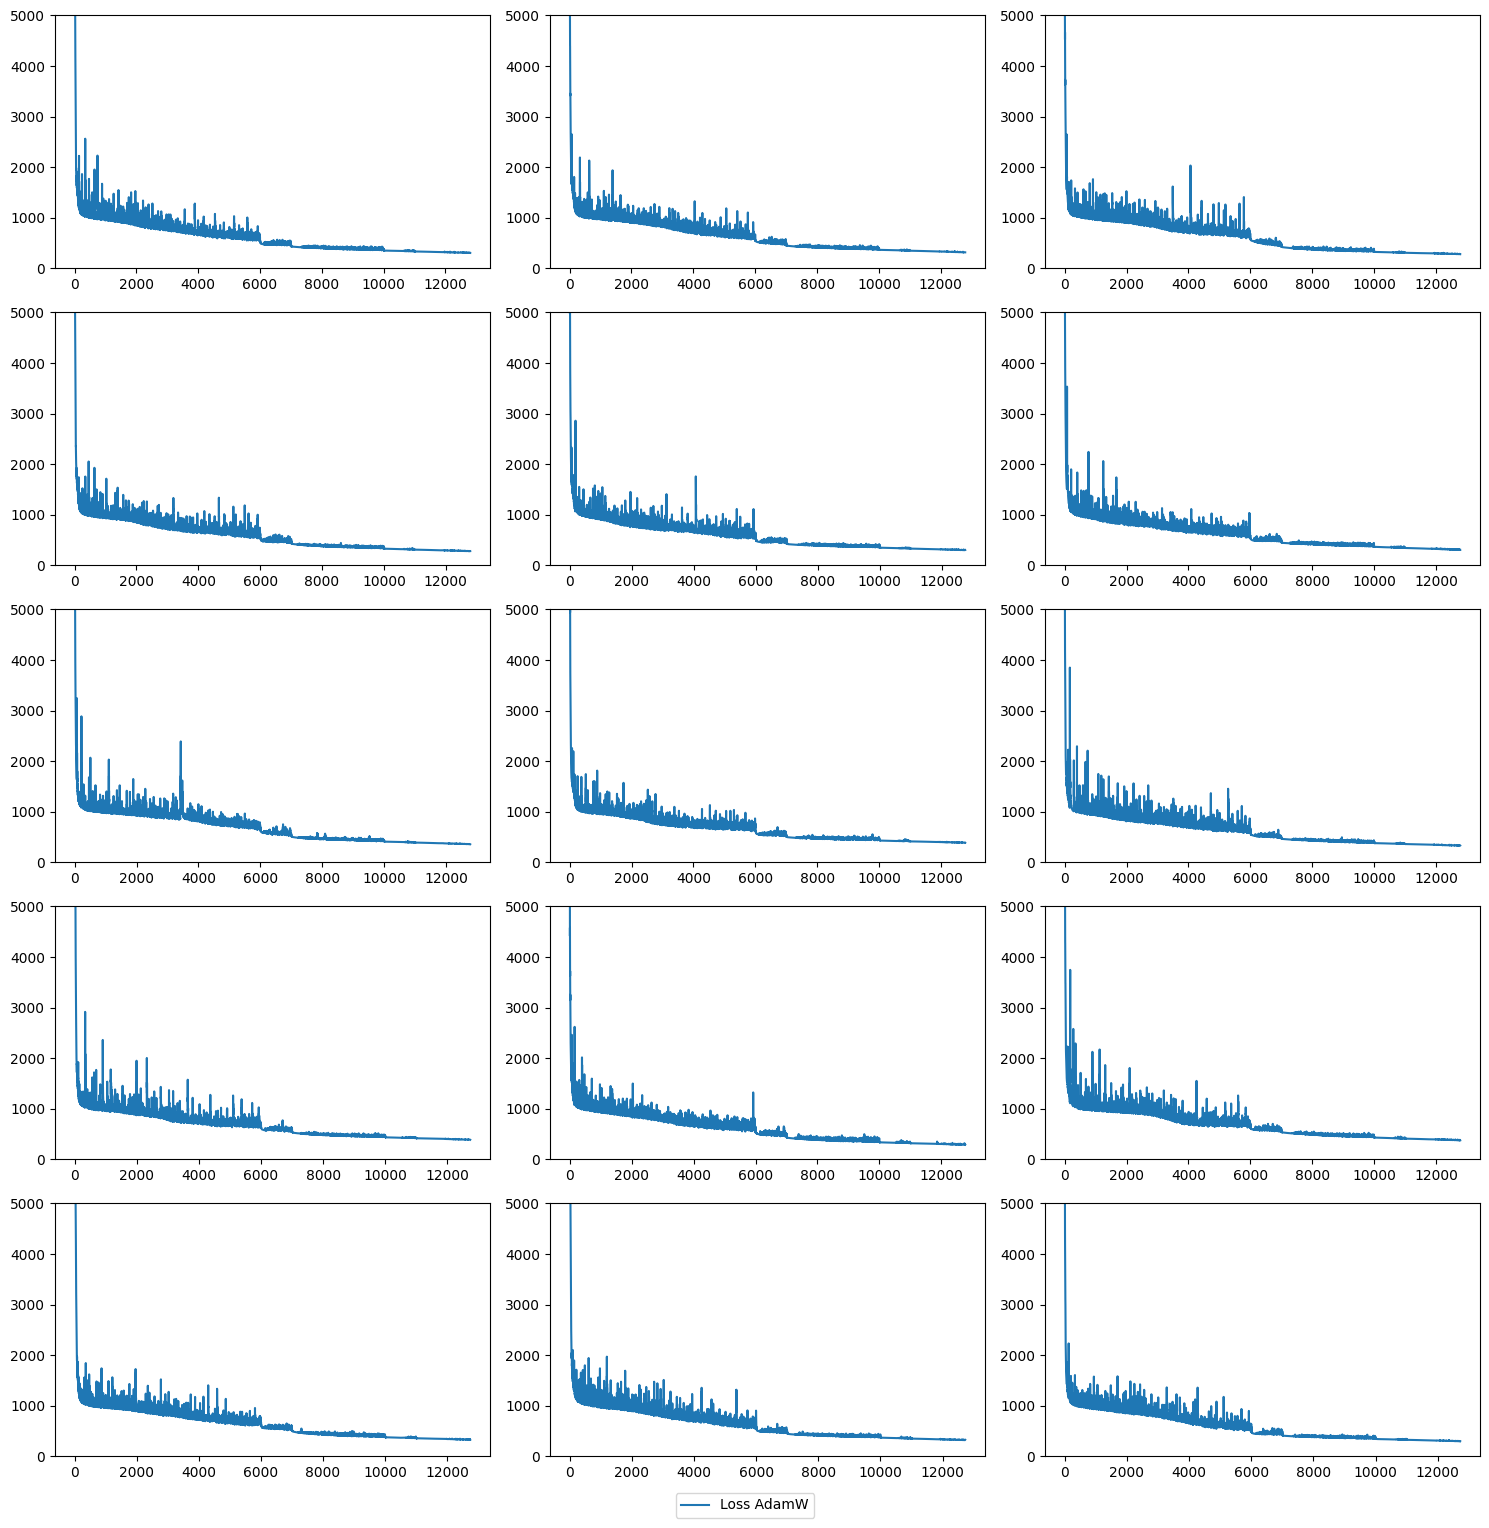

In [63]:
fig, axes = plt.subplots(nrows=n_models, ncols=len(pred_lambda), figsize=(15, 15))

# Jika hanya 1 model, axes akan menjadi 1D array → jadikan 2D untuk konsistensi indexing
if n_models == 1:
    axes = [axes]  # bungkus agar axes[0][j] bisa digunakan

for i in range(n_models):
    for j in range(len(pred_lambda)):
        axes[i][j].plot(
            np.linspace(0, len(hists_Adam_comb[i][j]), len(hists_Adam_comb[i][j])),
            hists_Adam_comb[i][j]
        )
        axes[i][j].set_ylim([0, 5e3])
        print(f"len Attempt-{i} Lambda ke- {j}: ", len(hists_Adam_comb[i][j]))
    print("\\\\")

fig.legend(['Loss AdamW'], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)
plt.tight_layout()
plt.show()


### Prediction and Evaluation

In [64]:
t_unique = np.sort(test_df['time'].unique())
x_unique = np.sort(test_df['x_coord'].unique())
y_unique = np.sort(test_df['y_coord'].unique())


In [65]:
lb = tf.constant(lb, dtype=tf.float32)
ub = tf.constant(ub, dtype=tf.float32)

In [66]:
train_Adam_comb = []


t_unique_train = np.sort(train_df['time'].unique())
x_unique_train = np.sort(train_df['x_coord'].unique())
y_unique_train = np.sort(train_df['y_coord'].unique())


for i in range(n_models):
  for j in range(len(pred_lambda)):
    train_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_train, t_unique_train, x_unique_train, y_unique_train))


In [67]:
df = pd.DataFrame(columns=['Adam_0.5','Adam_1','Adam_1.5'])
initial_lambdas = [0.5,1,1.5]

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = train_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_train.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam_0.5,Adam_1,Adam_1.5
Attempt 1,"(0.35332116, 16.351303)","(0.35873455, 16.560013)","(0.34763554, 16.241594)"
Attempt 2,"(0.33827314, 15.552507)","(0.35203862, 16.402664)","(0.3556979, 16.36607)"
Attempt 3,"(0.3828786, 17.764511)","(0.38864347, 18.12481)","(0.36600024, 16.962414)"
Attempt 4,"(0.3880471, 17.774796)","(0.34928733, 16.518913)","(0.38075975, 17.338758)"
Attempt 5,"(0.36465108, 16.76329)","(0.36077085, 16.526224)","(0.35192052, 16.389565)"


In [68]:
preds_Adam_comb = []

for i in range(n_models):
  for j in range(len(pred_lambda)):
    preds_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_test, t_unique, x_unique, y_unique))


In [75]:
df = pd.DataFrame(columns=['Adam_0.5','Adam_1','Adam_1.5'])

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = preds_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_test.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam_0.5,Adam_1,Adam_1.5
Attempt 1,"(0.37712198, 17.066864)","(0.38297462, 17.167147)","(0.36952645, 16.778004)"
Attempt 2,"(0.36018807, 16.198908)","(0.37689853, 17.082691)","(0.3794622, 16.975554)"
Attempt 3,"(0.4027337, 18.165161)","(0.40895408, 18.671612)","(0.39021474, 17.655533)"
Attempt 4,"(0.40978777, 18.389568)","(0.36978728, 17.038477)","(0.402042, 18.00425)"
Attempt 5,"(0.38667938, 17.409042)","(0.38453442, 17.160646)","(0.37475026, 17.140146)"


In [76]:
def summarise_attempts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a tidy table with mean, sample‑SD and CV
    for both numbers contained in each tuple cell.
    """
    summaries = {}
    for col in df.columns:
        arr = np.vstack(df[col].to_numpy())     # shape = (n_attempts, 2)
        μ  = arr.mean(axis=0)                   # mean
        σ  = arr.std(axis=0, ddof=1)            # sample SD (ddof=1)
        cv = σ / μ                              # coefficient of variation
        summaries[col] = {
            "mean_MAE": μ[0], "sd_MAE": σ[0], "cv_MAE": cv[0],
            "mean_MAPE": μ[1], "sd_MAPE": σ[1], "cv_MAPE": cv[1],
        }
    return pd.DataFrame(summaries).T

stats_df = summarise_attempts(df)
print(stats_df)

          mean_MAE    sd_MAE    cv_MAE  mean_MAPE   sd_MAPE   cv_MAPE
Adam_0.5  0.387302  0.019893  0.051363  17.445908  0.881457  0.050525
Adam_1    0.384630  0.014786  0.038442  17.424114  0.699461  0.040143
Adam_1.5  0.383199  0.013005  0.033939  17.310696  0.506236  0.029244


In [70]:
X_test[:, 0]

<tf.Tensor: shape=(57509,), dtype=float32, numpy=array([621., 701., 425., ..., 403., 133.,  80.], dtype=float32)>

In [71]:
import os

# Define the directory where you want to save the CSV files
output_dir = dir + "NO2Model/Fourier/predictions/tanh2" # Assuming 'dir' is defined

for i in range(n_models):
    for j in range(len(pred_lambda)):
        # Get the prediction for the current model and initial lambda
        current_pred = preds_Adam_comb[i * len(pred_lambda) + j].numpy()

        # Create a DataFrame from the prediction
        # You might want to include time, x, and y coordinates as well
        X_test_np = X_test.numpy()

        pred_df = pd.DataFrame({
            'time': X_test_np[:, 0],
            'x_coord': X_test_np[:, 1],
            'y_coord': X_test_np[:, 2],
            'predicted_NO2_mean': current_pred.flatten()
        })

        # Define the filename
        filename = f"prediction_model_{i+1}_lambda_{j+1}.csv"
        filepath = os.path.join(output_dir, filename)

        # Save the DataFrame to a CSV file
        pred_df.to_csv(filepath, index=False)

        print(f"Saved prediction to: {filepath}")

Saved prediction to: /content/drive/My Drive/TA/NO2Model/Fourier/predictions/tanh2/prediction_model_1_lambda_1.csv
Saved prediction to: /content/drive/My Drive/TA/NO2Model/Fourier/predictions/tanh2/prediction_model_1_lambda_2.csv
Saved prediction to: /content/drive/My Drive/TA/NO2Model/Fourier/predictions/tanh2/prediction_model_1_lambda_3.csv
Saved prediction to: /content/drive/My Drive/TA/NO2Model/Fourier/predictions/tanh2/prediction_model_2_lambda_1.csv
Saved prediction to: /content/drive/My Drive/TA/NO2Model/Fourier/predictions/tanh2/prediction_model_2_lambda_2.csv
Saved prediction to: /content/drive/My Drive/TA/NO2Model/Fourier/predictions/tanh2/prediction_model_2_lambda_3.csv
Saved prediction to: /content/drive/My Drive/TA/NO2Model/Fourier/predictions/tanh2/prediction_model_3_lambda_1.csv
Saved prediction to: /content/drive/My Drive/TA/NO2Model/Fourier/predictions/tanh2/prediction_model_3_lambda_2.csv
Saved prediction to: /content/drive/My Drive/TA/NO2Model/Fourier/predictions/tan

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import numpy as np # Make sure numpy is imported for np.round
import datetime as dt
output_dir = dir + "NO2Model/Fourier/predictions/tanh2/"

# Assuming X_test, u_test, and test_df are already loaded
# Convert X_test and u_test to numpy arrays for easier manipulation if they are not already
X_test_np = X_test.numpy() if isinstance(X_test, tf.Tensor) else X_test
u_test_np = u_test.numpy().flatten() if isinstance(u_test, tf.Tensor) else u_test.flatten()

# Ensure test_df is loaded and contains the 'city' column and 'date' column
# If not, load it or make sure it's available in your environment

# Extract city names and datetime objects from the original test_df
cities = test_df['city'].values
dates = test_df['date'].dt.date.values # Assuming 'date' column is already datetime


# n_models = 5
len_pred_lambda = 3 # Assuming the number of initial lambdas is 3

# Loop through models and initial lambdas to load and plot predictions
for i in range(n_models):
    for j in range(len_pred_lambda):
        # Construct the filename
        filename = f"prediction_model_{i+1}_lambda_{j+1}.csv"
        filepath = os.path.join(output_dir, filename)

        # Load the prediction data
        try:
            pred_df = pd.read_csv(filepath)
            print(f"Loaded prediction data from: {filepath}")
        except FileNotFoundError:
            print(f"Error: File not found at {filepath}. Skipping this file.")
            continue # Skip to the next iteration if the file is not found

        # Create a DataFrame for plotting, including 'date' and 'city'
        df = pd.DataFrame({
            'date': dates,
            'city': cities,
            'u_test': u_test_np,
            'u_pred': pred_df['predicted_NO2_mean'].values
        })

        # Pivot to get heatmap data using 'date' and 'city'
        heatmap_data_test = df.pivot_table(
            index='date',
            columns='city',
            values='u_test',
            aggfunc='mean' # Use mean if multiple entries for the same date and city exist
        )

        heatmap_data_pred = df.pivot_table(
            index='date',
            columns='city',
            values='u_pred',
            aggfunc='mean' # Use mean if multiple entries for the same date and city exist
        )

        # Determine shared color scale limits from the true data
        vmin = np.min(heatmap_data_test.min().min()) if not heatmap_data_test.empty else None
        vmax = np.max(heatmap_data_test.max().max()) if not heatmap_data_test.empty else None

        # Create the heatmap plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 15))

        # Plot true values with shared color scale
        if not heatmap_data_test.empty:
            sns.heatmap(heatmap_data_test, cmap='viridis', vmin=vmin, vmax=vmax, ax=ax1)
        ax1.set_title('True Values (u_test)')
        ax1.set_xlabel('City')
        ax1.set_ylabel('Date')

        # Plot predictions with shared color scale
        if not heatmap_data_pred.empty:
             sns.heatmap(heatmap_data_pred, cmap='viridis', vmin=vmin, vmax=vmax, ax=ax2)
        ax2.set_title(f'Predictions (u_pred) - Model {i+1}, Lambda {j+1}') # Dynamic title
        ax2.set_xlabel('City')
        ax2.set_ylabel('Date')

        plt.tight_layout()
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [73]:

# Loop through models and initial lambdas to load and plot predictions
for i in range(n_models):
    for j in range(len_pred_lambda):
        # Construct the filename
        filename = f"prediction_model_{i+1}_lambda_{j+1}.csv"
        filepath = os.path.join(output_dir, filename)

        # Load the prediction data
        try:
            pred_df = pd.read_csv(filepath)
            print(f"Loaded prediction data from: {filepath}")
        except FileNotFoundError:
            print(f"Error: File not found at {filepath}. Skipping this file.")
            continue # Skip to the next iteration if the file is not found

        # Create a DataFrame for plotting, including 'date' and 'city'
        df_recap = pd.DataFrame({
            'date': dates,
            'city': cities,
            'u_test': u_test_np,
            'u_pred': pred_df['predicted_NO2_mean'].values
        })
        nrows = 10
        ncols= 5
        unique_cities = df_recap['city'].unique()
        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
        axes = axes.flatten() # Flatten the axes array for easy indexing

        # Iterate through unique cities and plot on their respective subplots
        for city_idx, city in enumerate(unique_cities):
            city_df = df_recap[df_recap['city'] == city].copy()

            sns.lineplot(data=city_df, x='date', y='u_test', label='True', ax=axes[city_idx])
            sns.lineplot(data=city_df, x='date', y='u_pred', label='Predicted', ax=axes[city_idx])

            axes[city_idx].set_title(f'{city}')
            axes[city_idx].set_xlabel('Date')
            axes[city_idx].set_ylabel('NO2 Mean')
            axes[city_idx].tick_params(axis='x', rotation=45)
            axes[city_idx].grid(True)
            axes[city_idx].legend()

        # Hide any unused subplots if the number of cities is not a multiple of ncols
        for k in range(41, nrows * ncols):
            fig.delaxes(axes[k])

        fig.suptitle(f'NO2 Mean Over Time (Model-{i+1}, Lambda-{j+1})', fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [81]:
weights = models_Adam_comb[1][0].get_weights()

for i, w in enumerate(weights):
    print(f"Weight {i}: shape = {w.shape}")
    print(w)

Weight 0: shape = (3, 64)
[[ 3.86490792e-01 -2.91529328e-01 -2.71357685e-01  1.77960783e-01
   4.20286953e-01  3.40973020e-01 -2.32405454e-01  3.40673864e-01
   1.78839728e-01  3.74847323e-01  1.64202482e-01  1.41442418e-01
   3.55926514e-01  3.73464882e-01  3.96499634e-01  3.62298667e-01
  -4.03480113e-01 -2.37121180e-01 -5.24659781e-03  2.69164860e-01
  -3.10041428e-01 -2.32135311e-01  4.15311366e-01 -4.55603361e-01
   2.42440119e-01  1.77484944e-01  3.25385481e-01 -6.65029705e-01
  -2.56966323e-01 -4.03042942e-01 -4.34480965e-01  3.97007503e-02
   6.98751658e-02 -2.42385134e-01 -2.68855244e-01 -4.53307688e-01
  -4.37522978e-01  4.13595373e-03  2.34523177e-01  1.84298038e-01
  -4.69120353e-01  4.15943891e-01 -3.72550964e-01  1.40442133e-01
  -2.99149960e-01  3.58677834e-01 -5.80270112e-01  3.48285735e-01
   2.10380226e-01  3.56734186e-01  2.81244457e-01  4.09768015e-01
   2.29882061e-01  3.57180685e-01 -4.24362391e-01 -8.64815861e-02
  -3.72021616e-01  1.15965918e-01 -2.56575406e-01 

In [82]:
weights2 = models_Adam_comb[3][1].get_weights()

for i, w in enumerate(weights2):
    print(f"Weight {i}: shape = {w.shape}")
    print(w)

Weight 0: shape = (3, 64)
[[-0.49083063  0.2598184   0.15789655  0.19848955 -0.25166568 -0.3912498
   0.41126373 -0.19502765 -0.28775203 -0.42127278  0.48027855  0.39573482
  -0.06061188 -0.37778962 -0.02705891  0.2494593   0.12085618 -0.17282829
  -0.12513547 -0.12542011 -0.56048554 -0.01720633  0.5123456   0.10382786
  -0.05501719 -0.23890205  0.03392237  0.13984574  0.10351187  0.07337827
   0.03864934  0.10459803 -0.05174798  0.13433665 -0.23868772 -0.20192422
   0.2547356   0.26449695  0.50294906  0.26349312 -0.19272879  0.10945521
   0.4890429   0.520514   -0.21142696 -0.101539   -0.01107035  0.2958113
  -0.3467476  -0.1102611  -0.22191001  0.4565047  -0.57520586 -0.04261417
  -0.29554573 -0.03826995  0.13380708 -0.08837019  0.1263618   0.07866993
   0.58876485 -0.54408604 -0.5679732  -0.00365114]
 [-0.061637   -0.03871385  0.20229918  0.00845001  0.144625    0.10148519
  -0.21192493  0.00812702 -0.16960399 -0.08955845  0.02498291  0.10726365
  -0.09855178 -0.1344053   0.383718  

In [83]:
weights3 = models_Adam_comb[0][2].get_weights()

for i, w in enumerate(weights3):
    print(f"Weight {i}: shape = {w.shape}")
    print(w)

Weight 0: shape = (3, 64)
[[-0.06368107 -0.05723405 -0.32489747 -0.4898685   0.3888844   0.16524242
  -0.268595    0.6376615  -0.2638759   0.22752716 -0.47268635 -0.3420161
  -0.58966094  0.58272475 -0.307593    0.12616688  0.18849786  0.7629675
   0.13438073  0.15971266  0.61575097  0.09729051  0.11367344  0.6188552
  -0.45458856 -0.15640633 -0.42969975 -0.56145394 -0.03862177 -0.62338626
   0.3077245  -0.03603386 -0.15552345  0.38087222 -0.06303843 -0.20832293
   0.6134082   0.32753366 -0.30710024 -0.12304967  0.37251046  0.41134974
   0.49516872 -0.27048752 -0.630669    0.2884033   0.82664776 -0.30948147
   0.21388017  0.24433023  0.21983287 -0.30312267  0.5069447  -0.08980194
   0.4863176  -0.25078064 -0.4919087   0.21630602  0.5767694  -0.28011334
  -0.27410313 -0.26487967  0.39231297 -0.42269087]
 [-0.05474088 -0.32895446 -0.2134432   0.20027806  0.10953755  0.32645172
  -0.17374688 -0.20539139  0.20344588  0.2263051  -0.02410913 -0.01939898
   0.03805016 -0.26804104 -0.19940928 

In [79]:
# import numpy as np
# import pandas as pd
# import math
# import os
# from google.colab import files

# # --- 1. Load data dan siapkan grid (1e-4 spacing) ---

# # Misal Anda sudah memiliki filtered_df
# # Jika belum, upload:
# # uploaded = files.upload()
# # filtered_df = pd.read_csv("filtered_df.csv")

# step = 1e-2  # Resolusi

# t_min, t_max = filtered_df["time"].min(), filtered_df["time"].max()
# x_min, x_max = filtered_df["x_coord"].min(), filtered_df["x_coord"].max()
# y_min, y_max = filtered_df["y_coord"].min(), filtered_df["y_coord"].max()

# t_points = np.arange(t_min, t_max + step, 1, dtype=np.float32)
# x_points = np.arange(x_min, x_max + step, step, dtype=np.float32)
# y_points = np.arange(y_min, y_max + step, step, dtype=np.float32)


# target_indices = [(1, 0), (3, 1), (0, 2)]
# models_to_use  = [models_Adam_comb[i][j] for i, j in target_indices]
# model_labels   = [f"m{i}_{j}" for i, j in target_indices]
# file_paths     = [f"/content/prediction_Fourier2_tanh_{label}.csv" for label in model_labels]

# # --- 3. Generator grid untuk batch prediksi ---

# def gen_batches(t_vec, x_vec, y_vec, batch_size=250_000):
#     for t in t_vec:
#         xy_pairs = np.stack(np.meshgrid(x_vec, y_vec, indexing="ij"), -1).reshape(-1, 2)
#         t_col = np.full((xy_pairs.shape[0], 1), t, dtype=np.float32)
#         tx_y = np.hstack([t_col, xy_pairs])
#         n_rows = tx_y.shape[0]
#         n_batch = math.ceil(n_rows / batch_size)
#         for k in range(n_batch):
#             yield tx_y[k * batch_size : (k + 1) * batch_size]

# # --- 4. Buat 3 file kosong dengan header masing-masing ---

# for path in file_paths:
#     if os.path.exists(path):
#         os.remove(path)
#     with open(path, "w") as f:
#         f.write("t,x,y,prediction\n")  # header standar

# # --- 5. Proses batch demi batch dan tulis per model ke file masing-masing ---

# for batch in gen_batches(t_points, x_points, y_points):
#     for model, path in zip(models_to_use, file_paths):
#         pred = model.predict(batch, verbose=0).reshape(-1, 1)  # asumsi 1 kolom
#         output = np.hstack([batch, pred])
#         pd.DataFrame(output, columns=["t", "x", "y", "prediction"])\
#           .to_csv(path, mode="a", header=False, index=False, float_format="%.6g")



KeyboardInterrupt: 